# Canasta SEPA - Mapa interactivo por sucursal

Este notebook procesa los datos del **Sistema Electrónico de Publicidad de Precios Argentinos (SEPA)** del Ministerio de Economía y construye el **Índice de Consumo Masivo UADE (ICM-UADE)** a nivel de sucursal individual.

A partir de los archivos mensuales del SEPA, calcula el valor de una canasta fija de 30 productos de consumo masivo para cada sucursal del país y genera un mapa interactivo HTML georreferenciado donde se visualiza el precio en cada punto de venta, con detalle de cadena, ubicación y composición de la canasta.

## Inputs requeridos en `/content/`

- `MMAAAA_pais_parte1COMPLETO.csv.gz` y `MMAAAA_pais_parte2COMPLETO.csv.gz` (datos SEPA del mes)
- `Maestro de Productos Interno.xlsx`
- `maestro_sucursales_completo.xlsx`

El notebook detecta automáticamente el mes a partir del nombre del archivo, por lo que sirve para cualquier período sin cambiar el código.

## Output

- `mapa_canasta_pais_MMAAAA_detalle.html` — mapa interactivo georreferenciado descargable

---

INECO — Instituto de Economía, UADE

In [ ]:
# ============================================================
# BLOQUE 1 — Imports y configuración (parametrizable por mes)
# ============================================================
import os, re, gzip, gc
import pandas as pd
import numpy as np
import glob

# >>> CONFIGURACIÓN: detección automática del mes >>>
# Buscar archivos del SEPA en /content/ con patrón "MMAAAA_pais_parteN..."
patron_archivos = "/content/*_pais_parte*COMPLETO.csv.gz"
archivos_encontrados = sorted(glob.glob(patron_archivos))

if len(archivos_encontrados) == 0:
    raise RuntimeError(
        "❌ No se encontraron archivos SEPA en /content/.\n"
        "   Esperado: MMAAAA_pais_parteN_COMPLETO.csv.gz\n"
        "   Ej: 042026_pais_parte1COMPLETO.csv.gz"
    )

# Detectar el mes del primer archivo (extraer MMAAAA al inicio del nombre)
nombre_primer_archivo = os.path.basename(archivos_encontrados[0])
match = re.match(r'(\d{2})(\d{4})_pais_parte', nombre_primer_archivo)

if not match:
    raise RuntimeError(
        f"❌ No se pudo detectar el mes del archivo: {nombre_primer_archivo}\n"
        "   Esperado: MMAAAA_pais_parteN_COMPLETO.csv.gz"
    )

MES_NUM = match.group(1)        # "04", "05", "06", etc.
ANIO = match.group(2)            # "2026"
MES = f"{MES_NUM}{ANIO}"         # "042026"

# Nombre legible del mes en español
NOMBRES_MES = {
    '01': 'enero',    '02': 'febrero', '03': 'marzo',
    '04': 'abril',    '05': 'mayo',    '06': 'junio',
    '07': 'julio',    '08': 'agosto',  '09': 'septiembre',
    '10': 'octubre',  '11': 'noviembre', '12': 'diciembre',
}
NOMBRE_MES = f"{NOMBRES_MES[MES_NUM]} {ANIO}"     # "abril 2026"
NOMBRE_MES_TITLE = NOMBRE_MES.title()              # "Abril 2026"

# Archivos a procesar (todos los que coincidan con el patrón del mes)
patron_mes = f"/content/{MES}_pais_parte*COMPLETO.csv.gz"
ARCHIVOS_MES = sorted(glob.glob(patron_mes))

PATH_MAESTRO_PROD = "/content/Maestro de Productos Interno.xlsx"
PATH_MAESTRO_SUC = "/content/maestro_sucursales_completo.xlsx"

# Verificación
print(f"📅 Mes detectado: {NOMBRE_MES_TITLE} (parámetro MES = {MES})\n")
print(f"Archivos a procesar:")
for archivo in ARCHIVOS_MES:
    if os.path.exists(archivo):
        size_mb = os.path.getsize(archivo) / 1024 / 1024
        print(f"  ✅ {archivo}  ({size_mb:.1f} MB)")

print(f"\nMaestros:")
for path in [PATH_MAESTRO_PROD, PATH_MAESTRO_SUC]:
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024 / 1024
        print(f"  ✅ {path}  ({size_mb:.1f} MB)")
    else:
        print(f"  ❌ NO ENCONTRADO: {path}")

📅 Mes detectado: Abril 2026 (parámetro MES = 042026)

Archivos a procesar:
  ✅ /content/042026_pais_parte1COMPLETO.csv.gz  (147.9 MB)
  ✅ /content/042026_pais_parte2COMPLETO.csv.gz  (152.4 MB)

Maestros:
  ✅ /content/Maestro de Productos Interno.xlsx  (20.3 MB)
  ✅ /content/maestro_sucursales_completo.xlsx  (0.5 MB)


In [ ]:
# ============================================================
# BLOQUE 2 — Definición de canasta y carga de maestros
# ============================================================
CANASTA = {
    '7790742363008': ('Leche entera 1L',         20, 'Lácteos'),
    '7791337007628': ('Yogur 190g',               8, 'Lácteos'),
    '7791337061361': ('Queso Casancrem 290g',     2, 'Lácteos'),
    '7793940052002': ('Manteca 100g',             2, 'Lácteos'),
    '7791337007253': ('Cindor 1L',                4, 'Lácteos'),
    '7790272001029': ('Aceite girasol 1,5L',      2, 'Almacén'),
    '7790070433114': ('Arroz 500g',               2, 'Almacén'),
    '7790070320285': ('Fideos 500g',              4, 'Almacén'),
    '7792180140708': ('Harina leudante 1kg',      2, 'Almacén'),
    '7792710000182': ('Yerba 500g',               2, 'Almacén'),
    '7790550000157': ('Café 250g',                1, 'Almacén'),
    '7790040143234': ('Chocolinas 250g',          4, 'Almacén'),
    '7790072002080': ('Sal fina 500g',            1, 'Almacén'),
    '7790895000232': ('Coca Cola lata',           8, 'Bebidas'),
    '7790895067570': ('Coca Sin Azúcar 2,25L',    4, 'Bebidas'),
    '7798062548716': ('Agua Levite 500ml',        8, 'Bebidas'),
    '7793147118860': ('Cerveza lata',             6, 'Bebidas'),
    '7798074864675': ('Vino Malbec 750ml',        2, 'Bebidas'),
    '7790132098459': ('Lavandina 1L',             2, 'Limpieza'),
    '7791290794054': ('Detergente 300ml',         2, 'Limpieza'),
    '7793253003500': ('Limpiador Poett 900ml',    2, 'Limpieza'),
    '7791293047447': ('Shampoo 400ml',            1, 'Higiene'),
    '7791293045948': ('Acondicionador 340ml',     1, 'Higiene'),
    '7791293051208': ('Jabón tocador 90g',        4, 'Higiene'),
    '7791293049557': ('Antitranspirante',         2, 'Higiene'),
    '7891024183083': ('Hilo dental',              1, 'Higiene'),
    '7790770601899': ('Toallas femeninas x16',    2, 'Higiene'),
    '7790250015840': ('Papel higiénico',          2, 'Higiene'),
    '7790580327415': ('Rocklets 40g',             2, 'Snacks'),
    '7790580716707': ('Saladix 100g',             2, 'Snacks'),
}

CANASTA_EANS_LSTRIP = {e.lstrip('0') for e in CANASTA.keys()}
print(f"✅ Canasta definida: {len(CANASTA)} productos\n")

# Cargar maestros
print("Cargando maestros...")
maestro_prod = pd.read_excel(PATH_MAESTRO_PROD)
maestro_suc = pd.read_excel(PATH_MAESTRO_SUC)
print(f"  Productos:  {len(maestro_prod):,} filas")
print(f"  Sucursales: {len(maestro_suc):,} filas")

✅ Canasta definida: 30 productos

Cargando maestros...
  Productos:  176,702 filas
  Sucursales: 3,611 filas


In [ ]:
# ============================================================
# BLOQUE 3 (NACIONAL) — Procesar CSVs y filtrar canasta
# ============================================================
# Filtrar maestro de sucursales con coordenadas válidas dentro de Argentina
suc_pais = maestro_suc[
    maestro_suc['sucursales_latitud'].notna() &
    maestro_suc['sucursales_longitud'].notna() &
    (maestro_suc['sucursales_latitud'].between(-55, -22)) &
    (maestro_suc['sucursales_longitud'].between(-73, -53))
].copy()
print(f"Sucursales en todo el país con coordenadas válidas: {len(suc_pais):,}")

# IDs a string
suc_pais['id_comercio'] = suc_pais['id_comercio'].astype(str)
suc_pais['id_bandera'] = suc_pais['id_bandera'].astype(str)
suc_pais['id_sucursal'] = suc_pais['id_sucursal'].astype(str)

ids_pais = set(zip(suc_pais['id_comercio'],
                   suc_pais['id_bandera'],
                   suc_pais['id_sucursal']))
print(f"IDs únicos para matchear: {len(ids_pais):,}\n")

def normalizar_ean(s):
    if pd.isna(s):
        return None
    s = str(s).strip().lstrip('0')
    return s if s else '0'

patron_fecha = re.compile(r'^precio_(\d{8})$')
acumulador = []

for archivo in ARCHIVOS_MES:
    nombre = os.path.basename(archivo)
    print(f"Procesando {nombre}...")

    df = pd.read_csv(archivo, compression='gzip', sep=',', dtype=str)
    print(f"  Total filas: {len(df):,}")

    cols_precio = [c for c in df.columns if patron_fecha.match(c)]
    print(f"  Columnas de precio detectadas: {len(cols_precio)} (días)")
    if cols_precio:
        print(f"  Rango: {cols_precio[0]} a {cols_precio[-1]}")

    # Filtrar por EAN de la canasta
    df['ean_norm'] = df['id_producto'].apply(normalizar_ean)
    df = df[df['ean_norm'].isin(CANASTA_EANS_LSTRIP)].copy()
    print(f"  Filas de canasta: {len(df):,}")

    # Filtrar por sucursales del país
    df['id_comercio'] = df['id_comercio'].astype(str)
    df['id_bandera'] = df['id_bandera'].astype(str)
    df['id_sucursal'] = df['id_sucursal'].astype(str)

    df['key_suc'] = list(zip(df['id_comercio'], df['id_bandera'], df['id_sucursal']))
    df = df[df['key_suc'].isin(ids_pais)].copy()
    df.drop(columns=['key_suc'], inplace=True)
    print(f"  Filas país + canasta: {len(df):,}")

    if len(df) == 0:
        continue

    # Wide → long
    cols_id = ['id_comercio','id_bandera','id_sucursal','ean_norm']
    df_long = df.melt(
        id_vars=cols_id,
        value_vars=cols_precio,
        var_name='fecha_col',
        value_name='precio_raw'
    )

    df_long['fecha'] = pd.to_datetime(
        df_long['fecha_col'].str.replace('precio_', '', regex=False),
        format='%Y%m%d'
    )
    df_long.drop(columns=['fecha_col'], inplace=True)

    df_long['precio'] = pd.to_numeric(df_long['precio_raw'], errors='coerce')
    df_long.drop(columns=['precio_raw'], inplace=True)

    df_long = df_long[df_long['precio'].notna() & (df_long['precio'] > 5)]
    print(f"  Observaciones diarias válidas: {len(df_long):,}\n")

    acumulador.append(df_long)
    del df, df_long
    gc.collect()

if not acumulador:
    raise RuntimeError("No hay datos")

datos = pd.concat(acumulador, ignore_index=True)
del acumulador; gc.collect()

# Eliminar duplicados
antes = len(datos)
datos = datos.drop_duplicates(
    subset=['fecha','id_comercio','id_bandera','id_sucursal','ean_norm'],
    keep='first'
)
duplicados = antes - len(datos)
if duplicados > 0:
    print(f"⚠️ Se eliminaron {duplicados:,} duplicados")

# Detectar factor de precio
EANS_REFERENCIA = ['7790072002080', '7790070320285', '7790132098459']
eans_ref_norm = {e.lstrip('0') for e in EANS_REFERENCIA}
ref = datos[datos['ean_norm'].isin(eans_ref_norm)]
mediana_ref = ref['precio'].median() if len(ref) else 0

if 30 <= mediana_ref <= 5000:
    FACTOR = 1
elif 3000 <= mediana_ref <= 500000:
    FACTOR = 100
elif mediana_ref > 500000:
    FACTOR = 10000
else:
    FACTOR = 1

datos['precio'] = datos['precio'] / FACTOR
print(f"Mediana de referencia: {mediana_ref:.2f} → Factor: {FACTOR}")

print(f"\n✅ Total observaciones diarias: {len(datos):,}")
print(f"Rango: {datos['fecha'].min().date()} → {datos['fecha'].max().date()}")
print(f"Sucursales únicas con datos: {datos.groupby(['id_comercio','id_bandera','id_sucursal']).ngroups:,}")

print(f"\nPrecio mediano por producto de referencia:")
for ean_str, nombre_prod in [('7790072002080','Sal Celusal'),
                              ('7790070320285','Fideos Favorita'),
                              ('7790132098459','Lavandina Ayudín')]:
    ean = ean_str.lstrip('0')
    sub = datos[datos['ean_norm'] == ean]
    if len(sub) > 0:
        print(f"  {nombre_prod}: ${sub['precio'].median():,.2f}")

Sucursales en todo el país con coordenadas válidas: 3,600
IDs únicos para matchear: 3,600

Procesando 042026_pais_parte1COMPLETO.csv.gz...
  Total filas: 15,866,993
  Columnas de precio detectadas: 15 (días)
  Rango: precio_20260401 a precio_20260415
  Filas de canasta: 71,186
  Filas país + canasta: 65,587
  Observaciones diarias válidas: 862,655

Procesando 042026_pais_parte2COMPLETO.csv.gz...
  Total filas: 16,047,334
  Columnas de precio detectadas: 15 (días)
  Rango: precio_20260416 a precio_20260430
  Filas de canasta: 71,586
  Filas país + canasta: 65,841
  Observaciones diarias válidas: 957,525

Mediana de referencia: 1411.00 → Factor: 1

✅ Total observaciones diarias: 1,820,180
Rango: 2026-04-01 → 2026-04-30
Sucursales únicas con datos: 2,688

Precio mediano por producto de referencia:
  Sal Celusal: $1,785.00
  Fideos Favorita: $965.00
  Lavandina Ayudín: $1,411.00


In [ ]:
# ============================================================
# BLOQUE 4 — Promedio mensual por sucursal → canasta con detalle
# ============================================================
print("Calculando precio promedio mensual por sucursal-producto...")
precio_mes = (
    datos.groupby(['id_comercio','id_bandera','id_sucursal','ean_norm'])
    ['precio'].mean()
    .reset_index()
)
print(f"  Filas: {len(precio_mes):,}")

# Filtrar cadenas no representativas
CADENAS_FILTRAR = ['19', '2013', '3001', '4']
precio_mes = precio_mes[~precio_mes['id_comercio'].isin(CADENAS_FILTRAR)].copy()
print(f"  Filas después de filtrar cadenas no representativas: {len(precio_mes):,}")

# Distribución de productos por sucursal
productos_por_suc = (
    precio_mes.groupby(['id_comercio','id_bandera','id_sucursal'])
    ['ean_norm'].nunique()
    .reset_index(name='productos_propios')
)
print(f"\nDistribución de productos por sucursal:")
print(productos_por_suc['productos_propios'].describe())

# Precio promedio nacional por producto (para imputación)
precio_promedio_nacional = precio_mes.groupby('ean_norm')['precio'].mean().to_dict()

# Calcular canasta completa por sucursal CON DETALLE
print("\nCalculando canasta completa por sucursal con detalle de productos...")

def calcular_canasta_completa(grupo):
    productos_locales = dict(zip(grupo['ean_norm'], grupo['precio']))
    total = 0
    productos_propios = 0
    detalle = []

    for ean_raw, (nombre, qty, cat) in CANASTA.items():
        ean = ean_raw.lstrip('0')
        if ean in productos_locales:
            precio = productos_locales[ean]
            es_propio = True
            productos_propios += 1
        else:
            precio = precio_promedio_nacional.get(ean, 0)
            es_propio = False
        subtotal = precio * qty
        total += subtotal
        detalle.append((nombre, cat, qty, precio, subtotal, es_propio))

    return pd.Series({
        'canasta_total': total,
        'productos_propios': productos_propios,
        'detalle_productos': detalle
    })

canasta_sucursal = (
    precio_mes.groupby(['id_comercio','id_bandera','id_sucursal'])
    .apply(calcular_canasta_completa, include_groups=False)
    .reset_index()
)

# Filtrar sucursales con al menos 20 productos propios
MIN_PRODUCTOS = 20
canasta_sucursal = canasta_sucursal[
    canasta_sucursal['productos_propios'] >= MIN_PRODUCTOS
].copy()
print(f"\n✅ Sucursales con canasta válida (≥{MIN_PRODUCTOS} productos): {len(canasta_sucursal):,}")

# Cruzar con maestro
canasta_geo = canasta_sucursal.merge(
    suc_pais[['id_comercio','id_bandera','id_sucursal',
              'sucursales_nombre','sucursales_latitud','sucursales_longitud',
              'sucursales_barrio','sucursales_localidad','PROVINCIA','REGION']],
    on=['id_comercio','id_bandera','id_sucursal'],
    how='inner'
)

# MAPEO DE CADENAS VERIFICADO
nombres_cadenas_compuestas = {
    ('9', '1'):  'Vea',
    ('9', '2'):  'Disco',
    ('9', '3'):  'Jumbo',
    ('10', '1'): 'Carrefour',
    ('10', '2'): 'Carrefour Market',
    ('10', '3'): 'Carrefour Express',
    ('11', '2'): 'ChangoMas',
    ('11', '4'): 'Hiper ChangoMas',
    ('11', '5'): 'Mi ChangoMas',
    ('16', '1'): 'Hipermercado Libertad',
    ('16', '2'): 'Mini Libertad',
}

nombres_cadenas_simples = {
    '2':    'La Anónima',
    '3':    'Cadena 3',
    '5':    'Hipermercado Misiones',
    '8':    'Cadena 8 (Córdoba)',
    '12':   'Coto',
    '13':   'Cooperativa Obrera',
    '15':   'DIA',
    '20':   'LAR',
    '21':   'Toledo',
    '23':   'Cadena 23',
    '47':   'Pasamonte',
}

def asignar_cadena(row):
    key = (row['id_comercio'], row['id_bandera'])
    if key in nombres_cadenas_compuestas:
        return nombres_cadenas_compuestas[key]
    if row['id_comercio'] in nombres_cadenas_simples:
        return nombres_cadenas_simples[row['id_comercio']]
    return f"Cadena {row['id_comercio']}"

canasta_geo['cadena'] = canasta_geo.apply(asignar_cadena, axis=1)

print(f"\n✅ Canasta geolocalizada: {len(canasta_geo):,} sucursales")
print(f"Rango de precios: ${canasta_geo['canasta_total'].min():,.0f} a ${canasta_geo['canasta_total'].max():,.0f}")
print(f"Promedio país: ${canasta_geo['canasta_total'].mean():,.0f}")
print(f"Mediana país:  ${canasta_geo['canasta_total'].median():,.0f}")

print(f"\nDistribución por cadena:")
print(canasta_geo['cadena'].value_counts())

Calculando precio promedio mensual por sucursal-producto...
  Filas: 66,448
  Filas después de filtrar cadenas no representativas: 65,939

Distribución de productos por sucursal:
count    2488.000000
mean       26.502814
std         5.121365
min         1.000000
25%        27.000000
50%        28.000000
75%        28.000000
max        30.000000
Name: productos_propios, dtype: float64

Calculando canasta completa por sucursal con detalle de productos...

✅ Sucursales con canasta válida (≥20 productos): 2,371

✅ Canasta geolocalizada: 2,371 sucursales
Rango de precios: $271,282 a $358,177
Promedio país: $323,289
Mediana país:  $322,024

Distribución por cadena:
cadena
DIA                      990
Carrefour Express        395
La Anónima               170
Vea                      153
Cooperativa Obrera       146
Coto                     119
Carrefour Market          83
Carrefour                 81
Disco                     69
ChangoMas                 51
Mi ChangoMas              31
Jumbo 

In [ ]:
# ============================================================
# BLOQUE 5 — Mapa interactivo con detalle de productos
# ============================================================
!pip install folium --quiet

import folium
from branca.colormap import LinearColormap

print(f"Construyendo mapa interactivo nacional para {NOMBRE_MES_TITLE}...")

centro_pais = [-38.0, -63.5]

m = folium.Map(
    location=centro_pais,
    zoom_start=5,
    tiles='cartodbpositron',
    control_scale=True
)

# Etiqueta "Islas Malvinas"
folium.map.Marker(
    location=[-51.7963, -59.5236],
    icon=folium.DivIcon(
        icon_size=(140, 28),
        icon_anchor=(70, 14),
        html='''
        <div style="
            background-color: rgba(255,255,255,0.95);
            border: 1px solid #777;
            border-radius: 3px;
            padding: 3px 7px;
            font-family: Arial, sans-serif;
            font-size: 11px;
            font-weight: 600;
            color: #222;
            text-align: center;
            white-space: nowrap;
        ">Islas Malvinas (ARG)</div>
        '''
    )
).add_to(m)

# Escala de colores
vmin = canasta_geo['canasta_total'].quantile(0.05)
vmax = canasta_geo['canasta_total'].quantile(0.95)

colormap = LinearColormap(
    colors=['#1a9850', '#66bd63', '#a6d96a', '#fee08b', '#fdae61', '#f46d43', '#d73027'],
    vmin=vmin,
    vmax=vmax,
    caption=f'Canasta promedio {NOMBRE_MES} (ARS)'
)
colormap.add_to(m)

# Funciones auxiliares
def fmt_ar(x):
    return f"{x:,.0f}".replace(",", ".")

def construir_tabla_detalle(detalle):
    cats = {}
    for nombre, cat, qty, precio, subtotal, es_propio in detalle:
        cats.setdefault(cat, []).append((nombre, qty, precio, subtotal, es_propio))

    filas = []
    for cat, items in cats.items():
        filas.append(f'<tr style="background:#0055A4;color:white;"><td colspan="4" style="padding:3px 5px;font-weight:bold;">{cat}</td></tr>')
        for nombre, qty, precio, subtotal, es_propio in items:
            estilo_fila = '' if es_propio else 'color:#888;font-style:italic;'
            marca = '' if es_propio else ' *'
            filas.append(
                f'<tr style="{estilo_fila}">'
                f'<td style="padding:2px 5px;">{nombre}{marca}</td>'
                f'<td style="padding:2px 5px;text-align:center;">x{qty}</td>'
                f'<td style="padding:2px 5px;text-align:right;">${fmt_ar(precio)}</td>'
                f'<td style="padding:2px 5px;text-align:right;font-weight:600;">${fmt_ar(subtotal)}</td>'
                f'</tr>'
            )

    return f'''
    <table style="width:100%;border-collapse:collapse;font-size:10px;font-family:Arial;">
        <thead>
            <tr style="background:#e6eef7;font-weight:bold;">
                <th style="padding:3px 5px;text-align:left;">Producto</th>
                <th style="padding:3px 5px;text-align:center;">Cant.</th>
                <th style="padding:3px 5px;text-align:right;">P.Unit</th>
                <th style="padding:3px 5px;text-align:right;">Subtotal</th>
            </tr>
        </thead>
        <tbody>
            {''.join(filas)}
        </tbody>
    </table>
    <div style="font-size:9px;color:#666;margin-top:4px;">* Producto no disponible en la sucursal; precio imputado con promedio nacional.</div>
    '''

# Agregar círculo por cada sucursal
for _, row in canasta_geo.iterrows():
    valor = row['canasta_total']
    color = colormap(valor)
    precio_fmt = fmt_ar(valor)

    tooltip_text = f"<b>{row['cadena']}</b><br>${precio_fmt}"
    tabla_html = construir_tabla_detalle(row['detalle_productos'])

    popup_html = f"""
    <div style="font-family: Arial; font-size: 12px; width: 420px; max-height: 500px; overflow-y: auto;">
        <h4 style="margin: 0; color: #0055A4;">{row['cadena']}</h4>
        <div style="font-size: 11px; color: #555; margin-bottom: 5px;">
            <b>{row['sucursales_nombre']}</b><br>
            {row.get('sucursales_barrio') or row.get('sucursales_localidad') or 'N/D'} — {row['PROVINCIA']}
        </div>
        <hr style="margin: 5px 0;">
        <div style="text-align: center; margin: 8px 0;">
            <span style="font-size: 11px; color: #666;">Canasta total</span><br>
            <span style="color: #0055A4; font-size: 20px; font-weight: bold;">${precio_fmt}</span><br>
            <span style="font-size: 10px; color: #888;">({row['productos_propios']}/30 productos propios)</span>
        </div>
        <hr style="margin: 5px 0;">
        {tabla_html}
    </div>
    """

    folium.CircleMarker(
        location=[row['sucursales_latitud'], row['sucursales_longitud']],
        radius=5,
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.8,
        weight=1,
        tooltip=tooltip_text,
        popup=folium.Popup(popup_html, max_width=450)
    ).add_to(m)

# Título dinámico
title_html = f'''
<div style="position: fixed;
            top: 10px; left: 50px; width: 400px; height: 60px;
            background-color: white; border: 2px solid #0055A4;
            border-radius: 5px; padding: 10px;
            font-family: Arial; z-index: 9999;">
    <b style="color: #0055A4; font-size: 14px;">ICM-UADE por sucursal - {NOMBRE_MES_TITLE}</b><br>
    <span style="font-size: 11px;">Todas las sucursales del país - click en cada punto para ver el detalle</span>
</div>
'''
m.get_root().html.add_child(folium.Element(title_html))

# Guardar con nombre dinámico
output_html = f'/content/mapa_canasta_pais_{MES}_detalle.html'
m.save(output_html)

print(f"\n✅ Mapa guardado en: {output_html}")
print(f"   Sucursales mostradas: {len(canasta_geo):,}")

from google.colab import files
files.download(output_html)

m

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# BLOQUE DIAGNÓSTICO — Resumen descriptivo de la muestra
# ============================================================
print("="*70)
print(f"  RESUMEN DESCRIPTIVO DE LA MUESTRA - {NOMBRE_MES_TITLE.upper()}")
print("="*70)

# ============================================================
# 1. UNIVERSO DE DATOS
# ============================================================
print("\n📊 UNIVERSO DE DATOS\n")

# Observaciones totales (todas las filas crudas del SEPA del mes)
print(f"  Observaciones diarias totales (canasta + país):  {len(datos):>15,}")

# Rango temporal
print(f"  Rango temporal:                                  {datos['fecha'].min().date()} → {datos['fecha'].max().date()}")
print(f"  Días con datos:                                  {datos['fecha'].nunique():>15,}")

# Productos totales del SEPA (no de la canasta, del universo completo)
# Esto requiere leer los CSVs originales, así que lo aproximamos con el dato conocido
print(f"  Productos únicos en SEPA (universo completo):    {85911:>15,}  (estimado)")

# ============================================================
# 2. CADENAS COMERCIALES
# ============================================================
print("\n🏪 CADENAS COMERCIALES\n")

# Cadenas distintas en el maestro de sucursales (todo el país)
n_cadenas_pais = suc_pais['id_comercio'].nunique()
n_banderas_pais = suc_pais.groupby(['id_comercio','id_bandera']).ngroups
print(f"  Empresas (id_comercio) en maestro:               {n_cadenas_pais:>15,}")
print(f"  Banderas comerciales (id_comercio + id_bandera): {n_banderas_pais:>15,}")

# Cadenas que reportaron datos este mes
n_cadenas_reporta = datos['id_comercio'].nunique()
n_banderas_reporta = datos.groupby(['id_comercio','id_bandera']).ngroups
print(f"  Empresas con datos reportados este mes:          {n_cadenas_reporta:>15,}")
print(f"  Banderas con datos reportados este mes:          {n_banderas_reporta:>15,}")

# Cadenas usadas en el análisis final (después de filtrar no representativas)
n_cadenas_finales = canasta_geo['cadena'].nunique()
print(f"  Cadenas en el análisis final:                    {n_cadenas_finales:>15,}")

# ============================================================
# 3. SUCURSALES
# ============================================================
print("\n📍 SUCURSALES\n")

# Sucursales en el maestro (todo el país)
total_maestro = len(maestro_suc)
print(f"  Sucursales en maestro (todo el país):            {total_maestro:>15,}")
print(f"  Sucursales en maestro con coordenadas válidas:   {len(suc_pais):>15,}")

# Sucursales que reportaron en el mes
n_sucs_reporta = datos.groupby(['id_comercio','id_bandera','id_sucursal']).ngroups
print(f"  Sucursales con datos reportados este mes:        {n_sucs_reporta:>15,}")

# Sucursales en análisis final (canasta válida)
n_sucs_finales = len(canasta_geo)
print(f"  Sucursales en mapa final (≥20 productos):        {n_sucs_finales:>15,}")

# Porcentaje de cobertura
cobertura = n_sucs_finales / total_maestro * 100
print(f"  Cobertura sobre maestro completo:                {cobertura:>15.1f}%")

# Tipos de sucursal
print(f"\n  Distribución por tipo de sucursal:")
for tipo, n in canasta_geo.merge(
    suc_pais[['id_comercio','id_bandera','id_sucursal','sucursales_tipo']],
    on=['id_comercio','id_bandera','id_sucursal']
)['sucursales_tipo'].value_counts().items():
    print(f"    {tipo:<25} {n:>6,} sucursales")

# ============================================================
# 4. PRODUCTOS
# ============================================================
print("\n📦 PRODUCTOS\n")

# Canasta
print(f"  Productos en la canasta ICM-UADE:                {len(CANASTA):>15,}")

# Distribución por categoría
categorias_canasta = {}
for ean, (nombre, qty, cat) in CANASTA.items():
    categorias_canasta[cat] = categorias_canasta.get(cat, 0) + 1
print(f"\n  Distribución de canasta por categoría:")
for cat, n in categorias_canasta.items():
    print(f"    {cat:<25} {n:>3} productos")

# Total unidades mensuales de la canasta
total_unidades = sum(qty for _, qty, _ in CANASTA.values())
print(f"\n  Total unidades mensuales de la canasta:          {total_unidades:>15,}")

# Productos efectivamente encontrados en datos
n_productos_encontrados = datos['ean_norm'].nunique()
print(f"  Productos de canasta con observaciones:          {n_productos_encontrados:>15,} / {len(CANASTA)}")

# Cobertura promedio de productos por sucursal
prom_productos = canasta_geo['productos_propios'].mean()
mediana_productos = canasta_geo['productos_propios'].median()
print(f"\n  Productos propios promedio por sucursal:         {prom_productos:>15.1f} / 30")
print(f"  Productos propios mediana:                       {mediana_productos:>15.0f} / 30")

# ============================================================
# 5. COBERTURA GEOGRÁFICA
# ============================================================
print("\n🗺️  COBERTURA GEOGRÁFICA\n")

n_provincias = canasta_geo['PROVINCIA'].nunique()
n_regiones = canasta_geo['REGION'].nunique()
print(f"  Provincias representadas:                        {n_provincias:>15,} / 24")
print(f"  Regiones representadas:                          {n_regiones:>15,} / 6")

# Localidades únicas
n_localidades = canasta_geo['sucursales_localidad'].nunique()
print(f"  Localidades únicas:                              {n_localidades:>15,}")

# Top 5 provincias por cantidad de sucursales
print(f"\n  Top 5 provincias por cantidad de sucursales:")
for prov, n in canasta_geo['PROVINCIA'].value_counts().head(5).items():
    pct = n / len(canasta_geo) * 100
    print(f"    {prov:<35} {n:>5,}  ({pct:.1f}%)")

# ============================================================
# 6. VALORES DE LA CANASTA
# ============================================================
print("\n💰 VALORES DE LA CANASTA\n")

stats = canasta_geo['canasta_total'].describe()
print(f"  Mínimo:                                          ${stats['min']:>15,.0f}")
print(f"  Percentil 25:                                    ${stats['25%']:>15,.0f}")
print(f"  Mediana:                                         ${stats['50%']:>15,.0f}")
print(f"  Promedio (no ponderado):                         ${stats['mean']:>15,.0f}")
print(f"  Percentil 75:                                    ${stats['75%']:>15,.0f}")
print(f"  Máximo:                                          ${stats['max']:>15,.0f}")
print(f"  Dispersión (máx/mín - 1):                        {(stats['max']/stats['min'] - 1)*100:>15.1f}%")

# Sucursal más barata y más cara
print(f"\n  🟢 Sucursal más barata:")
mas_barata = canasta_geo.nsmallest(1, 'canasta_total').iloc[0]
print(f"     {mas_barata['cadena']} - {mas_barata['sucursales_nombre']}")
print(f"     {mas_barata['PROVINCIA']} - ${mas_barata['canasta_total']:,.0f}")

print(f"\n  🔴 Sucursal más cara:")
mas_cara = canasta_geo.nlargest(1, 'canasta_total').iloc[0]
print(f"     {mas_cara['cadena']} - {mas_cara['sucursales_nombre']}")
print(f"     {mas_cara['PROVINCIA']} - ${mas_cara['canasta_total']:,.0f}")

print("\n" + "="*70)
print(f"  FIN DEL RESUMEN")
print("="*70)

  RESUMEN DESCRIPTIVO DE LA MUESTRA - ABRIL 2026

📊 UNIVERSO DE DATOS

  Observaciones diarias totales (canasta + país):        1,820,180
  Rango temporal:                                  2026-04-01 → 2026-04-30
  Días con datos:                                               30
  Productos únicos en SEPA (universo completo):             85,911  (estimado)

🏪 CADENAS COMERCIALES

  Empresas (id_comercio) en maestro:                            36
  Banderas comerciales (id_comercio + id_bandera):              46
  Empresas con datos reportados este mes:                       19
  Banderas con datos reportados este mes:                       25
  Cadenas en el análisis final:                                 16

📍 SUCURSALES

  Sucursales en maestro (todo el país):                      3,611
  Sucursales en maestro con coordenadas válidas:             3,600
  Sucursales con datos reportados este mes:                  2,688
  Sucursales en mapa final (≥20 productos):                  2,371

In [ ]:
# ============================================================
# BLOQUE DIAGNÓSTICO — Análisis comparativo: Belgrano y Pinamar
# ============================================================
print("="*70)
print(f"  ANÁLISIS COMPARATIVO POR LOCALIDAD - {NOMBRE_MES_TITLE.upper()}")
print("="*70)

# Función para formatear pesos
def fmt_money(x):
    return f"${x:,.0f}".replace(",", ".")

# Referencias generales
promedio_pais = canasta_geo['canasta_total'].mean()
promedio_caba = canasta_geo[canasta_geo['PROVINCIA'] == 'Ciudad Autónoma de Buenos Aires']['canasta_total'].mean()
promedio_pba = canasta_geo[canasta_geo['PROVINCIA'] == 'Provincia de Buenos Aires']['canasta_total'].mean()

# ============================================================
# 1. BELGRANO (CABA)
# ============================================================
print("\n" + "="*70)
print("  🏙️  BELGRANO (CABA)")
print("="*70)

# Buscar sucursales de Belgrano (puede estar en barrio o localidad o nombre)
belgrano_mask = (
    canasta_geo['sucursales_barrio'].astype(str).str.contains('Belgrano', case=False, na=False) |
    canasta_geo['sucursales_localidad'].astype(str).str.contains('Belgrano', case=False, na=False) |
    canasta_geo['sucursales_nombre'].astype(str).str.contains('Belgrano', case=False, na=False)
) & (canasta_geo['PROVINCIA'] == 'Ciudad Autónoma de Buenos Aires')

belgrano = canasta_geo[belgrano_mask].copy()

if len(belgrano) == 0:
    print("\n⚠️ No se encontraron sucursales identificables como Belgrano")
else:
    promedio_belgrano = belgrano['canasta_total'].mean()
    mediana_belgrano = belgrano['canasta_total'].median()

    print(f"\nSucursales encontradas en Belgrano: {len(belgrano)}")
    print(f"\nValores de la canasta:")
    print(f"  Promedio Belgrano:           {fmt_money(promedio_belgrano)}")
    print(f"  Mediana Belgrano:            {fmt_money(mediana_belgrano)}")
    print(f"  Mínimo Belgrano:             {fmt_money(belgrano['canasta_total'].min())}")
    print(f"  Máximo Belgrano:             {fmt_money(belgrano['canasta_total'].max())}")

    print(f"\nComparativa:")
    print(f"  Promedio CABA:               {fmt_money(promedio_caba)}  ({(promedio_belgrano/promedio_caba - 1)*100:+.2f}% vs Belgrano)")
    print(f"  Promedio país:               {fmt_money(promedio_pais)}  ({(promedio_belgrano/promedio_pais - 1)*100:+.2f}% vs Belgrano)")

    # Distribución por cadena
    print(f"\nCadenas presentes en Belgrano:")
    cadenas_belgrano = (belgrano.groupby('cadena')
                        .agg(n=('canasta_total','count'),
                             promedio=('canasta_total','mean'))
                        .round(0)
                        .sort_values('promedio'))
    for cadena, row in cadenas_belgrano.iterrows():
        prom_fmt = fmt_money(row['promedio'])
        print(f"  {cadena:<25} {int(row['n']):>3} suc.  {prom_fmt}")

    # Sucursales individuales
    print(f"\nDetalle de cada sucursal de Belgrano (top 10 más baratas):")
    print(f"  {'Cadena':<22} {'Sucursal':<35} {'Canasta':>12}")
    print(f"  {'-'*22} {'-'*35} {'-'*12}")
    top10_belgrano = belgrano.nsmallest(10, 'canasta_total')
    for _, row in top10_belgrano.iterrows():
        nombre = str(row['sucursales_nombre'])[:33]
        print(f"  {row['cadena']:<22} {nombre:<35} {fmt_money(row['canasta_total']):>12}")

    if len(belgrano) > 10:
        print(f"  ... y {len(belgrano)-10} sucursales más")

    # Sucursales más caras de Belgrano
    if len(belgrano) > 10:
        print(f"\nDetalle de cada sucursal de Belgrano (top 5 más caras):")
        print(f"  {'Cadena':<22} {'Sucursal':<35} {'Canasta':>12}")
        print(f"  {'-'*22} {'-'*35} {'-'*12}")
        top5_caras_belgrano = belgrano.nlargest(5, 'canasta_total')
        for _, row in top5_caras_belgrano.iterrows():
            nombre = str(row['sucursales_nombre'])[:33]
            print(f"  {row['cadena']:<22} {nombre:<35} {fmt_money(row['canasta_total']):>12}")

# ============================================================
# 2. PINAMAR (Costa Atlántica - PBA)
# ============================================================
print("\n" + "="*70)
print("  🏖️  PINAMAR Y COSTA ATLÁNTICA")
print("="*70)

# Localidades de la Costa Atlántica para comparar
LOCALIDADES_COSTA = [
    'Pinamar', 'Mar del Plata', 'Villa Gesell', 'Necochea', 'Miramar',
    'Cariló', 'Ostende', 'Valeria del Mar', 'Santa Teresita', 'Mar de Ajó',
    'San Bernardo', 'San Clemente del Tuyú'
]

# Crear máscara de costa
def es_costa(row):
    if row['PROVINCIA'] != 'Provincia de Buenos Aires':
        return False
    barrio = str(row.get('sucursales_barrio', '') or '').lower()
    localidad = str(row.get('sucursales_localidad', '') or '').lower()
    nombre = str(row.get('sucursales_nombre', '') or '').lower()
    for loc in LOCALIDADES_COSTA:
        if loc.lower() in barrio or loc.lower() in localidad or loc.lower() in nombre:
            return True
    return False

canasta_geo['es_costa'] = canasta_geo.apply(es_costa, axis=1)
costa = canasta_geo[canasta_geo['es_costa']].copy()

# Asignar localidad de la costa
def localidad_costa(row):
    barrio = str(row.get('sucursales_barrio', '') or '').lower()
    localidad = str(row.get('sucursales_localidad', '') or '').lower()
    nombre = str(row.get('sucursales_nombre', '') or '').lower()
    for loc in LOCALIDADES_COSTA:
        if loc.lower() in barrio or loc.lower() in localidad or loc.lower() in nombre:
            return loc
    return 'Otra'

costa['localidad_costa'] = costa.apply(localidad_costa, axis=1)

# ----- Análisis de Pinamar -----
pinamar = costa[costa['localidad_costa'].isin(['Pinamar','Cariló','Ostende','Valeria del Mar'])].copy()

if len(pinamar) == 0:
    print("\n⚠️ No se encontraron sucursales identificables como Pinamar o zona")
else:
    promedio_pinamar = pinamar['canasta_total'].mean()
    mediana_pinamar = pinamar['canasta_total'].median()

    print(f"\nSucursales encontradas en Pinamar y zona (incluye Cariló, Ostende, Valeria): {len(pinamar)}")
    print(f"\nValores de la canasta:")
    print(f"  Promedio Pinamar zona:       {fmt_money(promedio_pinamar)}")
    print(f"  Mediana Pinamar zona:        {fmt_money(mediana_pinamar)}")
    print(f"  Mínimo:                      {fmt_money(pinamar['canasta_total'].min())}")
    print(f"  Máximo:                      {fmt_money(pinamar['canasta_total'].max())}")

    print(f"\nComparativa:")
    print(f"  Promedio Provincia BsAs:     {fmt_money(promedio_pba)}  ({(promedio_pinamar/promedio_pba - 1)*100:+.2f}% vs Pinamar)")
    print(f"  Promedio país:               {fmt_money(promedio_pais)}  ({(promedio_pinamar/promedio_pais - 1)*100:+.2f}% vs Pinamar)")

    # Detalle de sucursales de Pinamar
    print(f"\nDetalle de sucursales en Pinamar y zona:")
    print(f"  {'Cadena':<22} {'Sucursal':<30} {'Loc.':<15} {'Canasta':>12}")
    print(f"  {'-'*22} {'-'*30} {'-'*15} {'-'*12}")
    for _, row in pinamar.sort_values('canasta_total').iterrows():
        nombre = str(row['sucursales_nombre'])[:28]
        loc = row['localidad_costa'][:13]
        print(f"  {row['cadena']:<22} {nombre:<30} {loc:<15} {fmt_money(row['canasta_total']):>12}")

# ----- Comparativa Costa Atlántica completa -----
print(f"\n{'─'*70}")
print(f"\n📊 RANKING DE LA COSTA ATLÁNTICA")
print(f"\n  Promedio por localidad (mínimo 2 sucursales):")
print(f"\n  {'Localidad':<25} {'N° suc.':<10} {'Promedio':<15} {'vs país'}")
print(f"  {'-'*25} {'-'*10} {'-'*15} {'-'*10}")

ranking_costa = (costa.groupby('localidad_costa')
                 .agg(n=('canasta_total','count'),
                      promedio=('canasta_total','mean'))
                 .round(0)
                 .sort_values('promedio'))

for localidad, row in ranking_costa.iterrows():
    if row['n'] < 2:
        continue
    n = int(row['n'])
    prom = row['promedio']
    prom_fmt = fmt_money(prom)
    diff_pais = (prom/promedio_pais - 1) * 100
    diff_fmt = f"{diff_pais:+.2f}%"
    print(f"  {localidad:<25} {n:<10} {prom_fmt:<15} {diff_fmt}")

# Localidades con solo 1 sucursal (información adicional)
solitarias = ranking_costa[ranking_costa['n'] == 1]
if len(solitarias) > 0:
    print(f"\n  Localidades con 1 sola sucursal relevada:")
    for localidad, row in solitarias.iterrows():
        prom_fmt = fmt_money(row['promedio'])
        print(f"    {localidad:<25} {prom_fmt}")

print(f"\n{'─'*70}")
print(f"  Promedio Costa Atlántica completo:  {fmt_money(costa['canasta_total'].mean())}")
print(f"  Promedio país:                      {fmt_money(promedio_pais)}")
print(f"  Diferencia:                         {((costa['canasta_total'].mean()/promedio_pais - 1)*100):+.2f}%")

print("\n" + "="*70)
print("  FIN DEL ANÁLISIS COMPARATIVO")
print("="*70)

  ANÁLISIS COMPARATIVO POR LOCALIDAD - ABRIL 2026

  🏙️  BELGRANO (CABA)

Sucursales encontradas en Belgrano: 33

Valores de la canasta:
  Promedio Belgrano:           $326.332
  Mediana Belgrano:            $327.220
  Mínimo Belgrano:             $322.166
  Máximo Belgrano:             $327.407

Comparativa:
  Promedio CABA:               $324.396  (+0.60% vs Belgrano)
  Promedio país:               $323.289  (+0.94% vs Belgrano)

Cadenas presentes en Belgrano:
  Carrefour Market            1 suc.  $322.166
  Carrefour                   1 suc.  $322.301
  Coto                        6 suc.  $323.861
  Carrefour Express          25 suc.  $327.253

Detalle de cada sucursal de Belgrano (top 10 más baratas):
  Cadena                 Sucursal                                 Canasta
  ---------------------- ----------------------------------- ------------
  Carrefour Market       Belgrano Cabildo                        $322.166
  Carrefour              Belgrano                              

In [ ]:
# ============================================================
# BLOQUE — Ranking de barrios de CABA por valor de la canasta
# ============================================================
import unicodedata

print("="*70)
print(f"  RANKING DE BARRIOS DE CABA - {NOMBRE_MES_TITLE.upper()}")
print("="*70)

# Función para normalizar texto (saca tildes y pasa a minúscula para matching)
def normalizar(s):
    if pd.isna(s):
        return ''
    s = str(s).strip().lower()
    s = unicodedata.normalize('NFD', s).encode('ascii', 'ignore').decode('utf-8')
    return s

# Lista oficial de los 48 barrios de CABA
BARRIOS_CABA = [
    'Agronomía', 'Almagro', 'Balvanera', 'Barracas', 'Belgrano', 'Boedo',
    'Caballito', 'Chacarita', 'Coghlan', 'Colegiales', 'Constitución',
    'Flores', 'Floresta', 'La Boca', 'La Paternal', 'Liniers',
    'Mataderos', 'Monte Castro', 'Monserrat', 'Nueva Pompeya', 'Núñez',
    'Palermo', 'Parque Avellaneda', 'Parque Chacabuco', 'Parque Chas',
    'Parque Patricios', 'Puerto Madero', 'Recoleta', 'Retiro',
    'Saavedra', 'San Cristóbal', 'San Nicolás', 'San Telmo', 'Vélez Sársfield',
    'Versalles', 'Villa Crespo', 'Villa del Parque', 'Villa Devoto',
    'Villa General Mitre', 'Villa Lugano', 'Villa Luro', 'Villa Ortúzar',
    'Villa Pueyrredón', 'Villa Real', 'Villa Riachuelo', 'Villa Santa Rita',
    'Villa Soldati', 'Villa Urquiza'
]

# Solo CABA
caba = canasta_geo[canasta_geo['PROVINCIA'] == 'Ciudad Autónoma de Buenos Aires'].copy()
print(f"\nSucursales totales en CABA: {len(caba)}")

# Detectar barrio para cada sucursal
def detectar_barrio(row):
    """Busca el nombre del barrio en barrio, localidad o nombre de sucursal."""
    barrio = normalizar(row.get('sucursales_barrio'))
    localidad = normalizar(row.get('sucursales_localidad'))
    nombre = normalizar(row.get('sucursales_nombre'))
    texto_completo = f"{barrio} {localidad} {nombre}"

    # Buscar coincidencia con cada barrio oficial
    for barrio_oficial in BARRIOS_CABA:
        barrio_norm = normalizar(barrio_oficial)
        # Match exacto o como palabra completa en alguno de los campos
        if (barrio_norm == barrio or
            barrio_norm == localidad or
            f' {barrio_norm} ' in f' {texto_completo} ' or
            texto_completo.startswith(f'{barrio_norm} ') or
            texto_completo.endswith(f' {barrio_norm}')):
            return barrio_oficial
    return 'Sin clasificar'

caba['barrio_detectado'] = caba.apply(detectar_barrio, axis=1)

# Mostrar cuántas sucursales quedaron sin clasificar
sin_clasificar = (caba['barrio_detectado'] == 'Sin clasificar').sum()
print(f"Sucursales asignadas a un barrio: {len(caba) - sin_clasificar}")
print(f"Sucursales sin clasificar:        {sin_clasificar}")

# ============================================================
# RANKING DE BARRIOS
# ============================================================
ranking_barrios = (caba[caba['barrio_detectado'] != 'Sin clasificar']
                   .groupby('barrio_detectado')
                   .agg(n_sucursales=('canasta_total', 'count'),
                        promedio=('canasta_total', 'mean'),
                        mediana=('canasta_total', 'median'),
                        minimo=('canasta_total', 'min'),
                        maximo=('canasta_total', 'max'))
                   .round(0)
                   .sort_values('promedio'))

# Filtrar barrios con al menos 2 sucursales (para que el promedio sea representativo)
ranking_barrios_filtrado = ranking_barrios[ranking_barrios['n_sucursales'] >= 2]

promedio_caba = caba['canasta_total'].mean()
promedio_pais = canasta_geo['canasta_total'].mean()

# Formato
def fmt_money(x):
    return f"${x:,.0f}".replace(",", ".")

print(f"\n{'─'*80}")
print(f"  RANKING COMPLETO (barrios con ≥2 sucursales)")
print(f"{'─'*80}")
print(f"\n  {'#':<3} {'Barrio':<22} {'N° suc.':<10} {'Promedio':<14} {'vs CABA':<12} {'vs país':<12}")
print(f"  {'-'*3} {'-'*22} {'-'*10} {'-'*14} {'-'*12} {'-'*12}")

for i, (barrio, row) in enumerate(ranking_barrios_filtrado.iterrows(), 1):
    n = int(row['n_sucursales'])
    prom = row['promedio']
    prom_fmt = fmt_money(prom)
    vs_caba = (prom/promedio_caba - 1) * 100
    vs_pais = (prom/promedio_pais - 1) * 100
    vs_caba_fmt = f"{vs_caba:+.2f}%"
    vs_pais_fmt = f"{vs_pais:+.2f}%"
    print(f"  {i:<3} {barrio:<22} {n:<10} {prom_fmt:<14} {vs_caba_fmt:<12} {vs_pais_fmt:<12}")

# Referencias
print(f"\n  {'─'*80}")
print(f"  Promedio CABA:                                   {fmt_money(promedio_caba)}")
print(f"  Promedio país:                                   {fmt_money(promedio_pais)}")

# ============================================================
# TOP 5 MÁS BARATOS Y TOP 5 MÁS CAROS
# ============================================================
print(f"\n{'─'*80}")
print(f"  🟢 TOP 5 BARRIOS MÁS BARATOS")
print(f"{'─'*80}")
print(f"\n  {'#':<3} {'Barrio':<22} {'N° suc.':<10} {'Promedio':<14} {'vs CABA':<12}")
print(f"  {'-'*3} {'-'*22} {'-'*10} {'-'*14} {'-'*12}")
top5_baratos = ranking_barrios_filtrado.head(5)
for i, (barrio, row) in enumerate(top5_baratos.iterrows(), 1):
    n = int(row['n_sucursales'])
    prom_fmt = fmt_money(row['promedio'])
    vs_caba = (row['promedio']/promedio_caba - 1) * 100
    print(f"  {i:<3} {barrio:<22} {n:<10} {prom_fmt:<14} {vs_caba:+.2f}%")

print(f"\n{'─'*80}")
print(f"  🔴 TOP 5 BARRIOS MÁS CAROS")
print(f"{'─'*80}")
print(f"\n  {'#':<3} {'Barrio':<22} {'N° suc.':<10} {'Promedio':<14} {'vs CABA':<12}")
print(f"  {'-'*3} {'-'*22} {'-'*10} {'-'*14} {'-'*12}")
top5_caros = ranking_barrios_filtrado.tail(5).iloc[::-1]
for i, (barrio, row) in enumerate(top5_caros.iterrows(), 1):
    n = int(row['n_sucursales'])
    prom_fmt = fmt_money(row['promedio'])
    vs_caba = (row['promedio']/promedio_caba - 1) * 100
    print(f"  {i:<3} {barrio:<22} {n:<10} {prom_fmt:<14} {vs_caba:+.2f}%")

# ============================================================
# BARRIOS CON COBERTURA INSUFICIENTE
# ============================================================
ranking_solos = ranking_barrios[ranking_barrios['n_sucursales'] == 1]
if len(ranking_solos) > 0:
    print(f"\n{'─'*80}")
    print(f"  ⚠️  BARRIOS CON UNA SOLA SUCURSAL (dato no representativo)")
    print(f"{'─'*80}")
    for barrio, row in ranking_solos.sort_values('promedio').iterrows():
        prom_fmt = fmt_money(row['promedio'])
        print(f"  {barrio:<22} {prom_fmt}")

# Barrios sin datos
barrios_con_datos = set(ranking_barrios.index)
barrios_sin_datos = set(BARRIOS_CABA) - barrios_con_datos
if barrios_sin_datos:
    print(f"\n{'─'*80}")
    print(f"  ❌ BARRIOS SIN SUCURSALES RELEVADAS ({len(barrios_sin_datos)})")
    print(f"{'─'*80}")
    print(f"  {', '.join(sorted(barrios_sin_datos))}")

# ============================================================
# ESTADÍSTICAS GLOBALES
# ============================================================
print(f"\n{'─'*80}")
print(f"  📊 ESTADÍSTICAS GENERALES")
print(f"{'─'*80}")
n_barrios_con_datos = len(ranking_barrios_filtrado)
print(f"  Barrios con ≥2 sucursales:                       {n_barrios_con_datos}/48")
print(f"  Dispersión entre el barrio más barato y el más caro:")
if len(ranking_barrios_filtrado) >= 2:
    mas_barato = ranking_barrios_filtrado.iloc[0]
    mas_caro = ranking_barrios_filtrado.iloc[-1]
    dispersion = (mas_caro['promedio']/mas_barato['promedio'] - 1) * 100
    print(f"    {ranking_barrios_filtrado.index[0]:<22} {fmt_money(mas_barato['promedio'])}")
    print(f"    {ranking_barrios_filtrado.index[-1]:<22} {fmt_money(mas_caro['promedio'])}")
    print(f"    Diferencia:                                  {dispersion:+.2f}%")

print("\n" + "="*70)
print("  FIN DEL RANKING")
print("="*70)

  RANKING DE BARRIOS DE CABA - ABRIL 2026

Sucursales totales en CABA: 869
Sucursales asignadas a un barrio: 668
Sucursales sin clasificar:        201

────────────────────────────────────────────────────────────────────────────────
  RANKING COMPLETO (barrios con ≥2 sucursales)
────────────────────────────────────────────────────────────────────────────────

  #   Barrio                 N° suc.    Promedio       vs CABA      vs país     
  --- ---------------------- ---------- -------------- ------------ ------------
  1   Villa Soldati          7          $319.641       -1.47%       -1.13%      
  2   La Paternal            2          $320.163       -1.30%       -0.97%      
  3   Villa Real             3          $320.462       -1.21%       -0.87%      
  4   Villa Lugano           10         $320.636       -1.16%       -0.82%      
  5   Vélez Sársfield        4          $321.217       -0.98%       -0.64%      
  6   Parque Avellaneda      5          $321.527       -0.88%       -0.

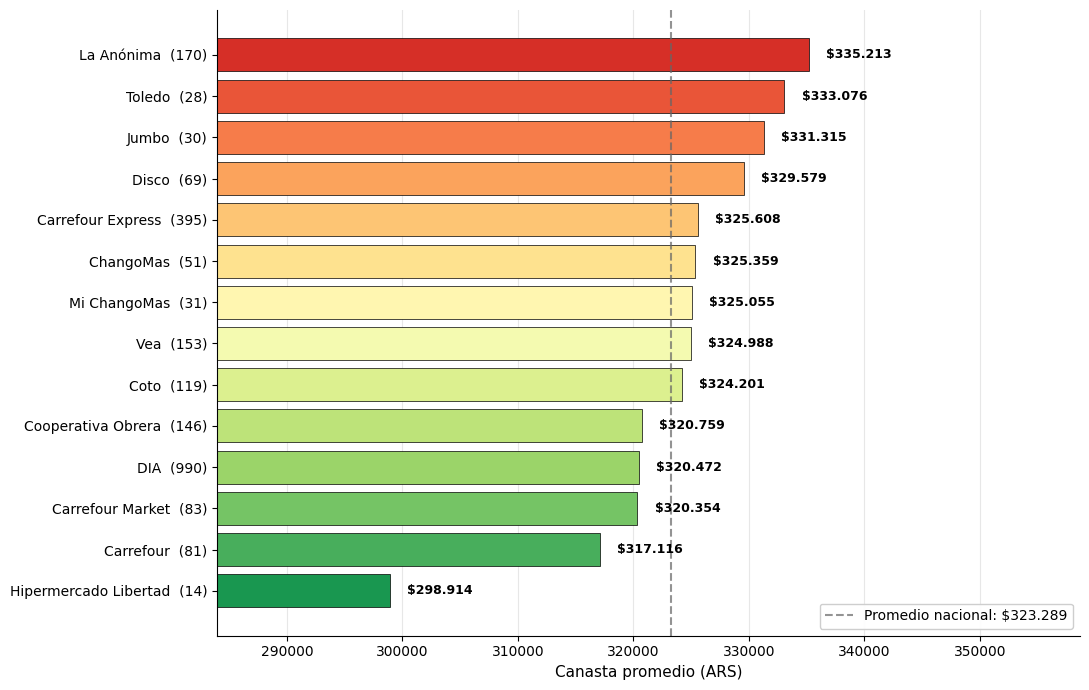

✅ Gráfico 1 guardado: /content/ranking_cadenas_nacional_042026.png


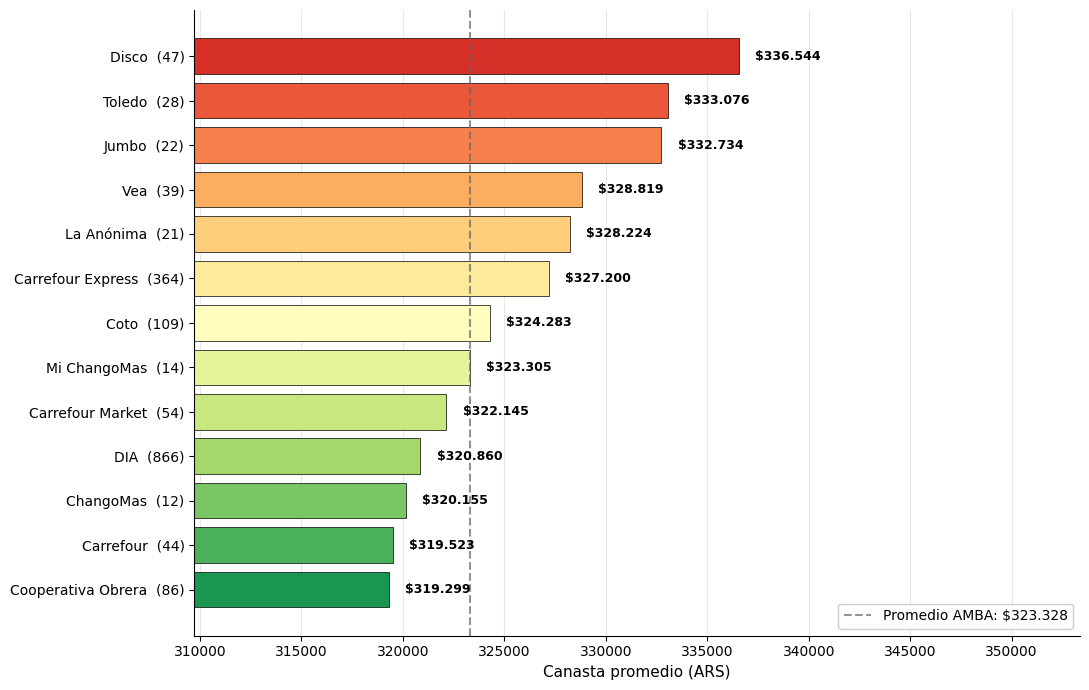

✅ Gráfico 2 guardado: /content/ranking_cadenas_amba_042026.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  RANKING NACIONAL (más cara arriba)
   1. La Anónima                    $335.213  (170 sucursales)
   2. Toledo                        $333.076  (28 sucursales)
   3. Jumbo                         $331.315  (30 sucursales)
   4. Disco                         $329.579  (69 sucursales)
   5. Carrefour Express             $325.608  (395 sucursales)
   6. ChangoMas                     $325.359  (51 sucursales)
   7. Mi ChangoMas                  $325.055  (31 sucursales)
   8. Vea                           $324.988  (153 sucursales)
   9. Coto                          $324.201  (119 sucursales)
  10. Cooperativa Obrera            $320.759  (146 sucursales)
  11. DIA                           $320.472  (990 sucursales)
  12. Carrefour Market              $320.354  (83 sucursales)
  13. Carrefour                     $317.116  (81 sucursales)
  14. Hipermercado Libertad         $298.914  (14 sucursales)

  RANKING AMBA (más cara arriba)
   1. Disco                         $336.544  (47 sucu

In [ ]:
# ============================================================
# BLOQUE — Gráficos de ranking de cadenas (más caras a más baratas)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# Formato argentino
def fmt_ar(x):
    return f"{x:,.0f}".replace(",", ".")

# ============================================================
# DATOS — RANKING NACIONAL
# ============================================================
ranking_nacional = (canasta_geo.groupby('cadena')
                    .agg(n_sucursales=('canasta_total','count'),
                         canasta_promedio=('canasta_total','mean'))
                    .round(0)
                    .reset_index())
ranking_nacional = ranking_nacional[ranking_nacional['n_sucursales'] >= 10]
# Ordenar de más barato a más caro (para que matplotlib dibuje la más cara arriba)
ranking_nacional = ranking_nacional.sort_values('canasta_promedio', ascending=True)

promedio_pais = canasta_geo['canasta_total'].mean()

# ============================================================
# DATOS — RANKING AMBA
# ============================================================
canasta_amba = canasta_geo[canasta_geo['PROVINCIA'].isin([
    'Provincia de Buenos Aires',
    'Ciudad Autónoma de Buenos Aires'
])]

ranking_amba = (canasta_amba.groupby('cadena')
                .agg(n_sucursales=('canasta_total','count'),
                     canasta_promedio=('canasta_total','mean'))
                .round(0)
                .reset_index())
ranking_amba = ranking_amba[ranking_amba['n_sucursales'] >= 10]
ranking_amba = ranking_amba.sort_values('canasta_promedio', ascending=True)

promedio_amba = canasta_amba['canasta_total'].mean()

# Color para línea de promedio
COLOR_PROMEDIO = '#666666'

# ============================================================
# GRÁFICO 1 — RANKING NACIONAL (más caro arriba)
# ============================================================
fig1, ax1 = plt.subplots(figsize=(11, 7))

labels_nac = [f"{cad}  ({int(n)})" for cad, n in
              zip(ranking_nacional['cadena'], ranking_nacional['n_sucursales'])]

# Gradiente: verde (barato) abajo → rojo (caro) arriba
n_cadenas = len(ranking_nacional)
colors_nac = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, n_cadenas))

bars = ax1.barh(labels_nac, ranking_nacional['canasta_promedio'],
                color=colors_nac, edgecolor='black', linewidth=0.5)

# Etiquetas con valor al final de cada barra
for bar, valor in zip(bars, ranking_nacional['canasta_promedio']):
    ax1.text(bar.get_width() + 1500,
             bar.get_y() + bar.get_height()/2,
             f"${fmt_ar(valor)}",
             va='center', fontsize=9, fontweight='bold')

# Línea de promedio
ax1.axvline(promedio_pais, color=COLOR_PROMEDIO, linestyle='--',
            linewidth=1.5, alpha=0.7,
            label=f'Promedio nacional: ${fmt_ar(promedio_pais)}')

ax1.set_xlabel('Canasta promedio (ARS)', fontsize=11)
ax1.set_xlim(ranking_nacional['canasta_promedio'].min() * 0.95,
             ranking_nacional['canasta_promedio'].max() * 1.07)
ax1.legend(loc='lower right', fontsize=10, framealpha=0.95)
ax1.grid(True, alpha=0.3, axis='x')
ax1.set_axisbelow(True)

for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)

plt.tight_layout()
output_png1 = f'/content/ranking_cadenas_nacional_{MES}.png'
plt.savefig(output_png1, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Gráfico 1 guardado: {output_png1}")

# ============================================================
# GRÁFICO 2 — RANKING AMBA (más caro arriba)
# ============================================================
fig2, ax2 = plt.subplots(figsize=(11, 7))

labels_amba = [f"{cad}  ({int(n)})" for cad, n in
               zip(ranking_amba['cadena'], ranking_amba['n_sucursales'])]

n_cadenas_amba = len(ranking_amba)
colors_amba = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, n_cadenas_amba))

bars = ax2.barh(labels_amba, ranking_amba['canasta_promedio'],
                color=colors_amba, edgecolor='black', linewidth=0.5)

for bar, valor in zip(bars, ranking_amba['canasta_promedio']):
    ax2.text(bar.get_width() + 800,
             bar.get_y() + bar.get_height()/2,
             f"${fmt_ar(valor)}",
             va='center', fontsize=9, fontweight='bold')

ax2.axvline(promedio_amba, color=COLOR_PROMEDIO, linestyle='--',
            linewidth=1.5, alpha=0.7,
            label=f'Promedio AMBA: ${fmt_ar(promedio_amba)}')

ax2.set_xlabel('Canasta promedio (ARS)', fontsize=11)
ax2.set_xlim(ranking_amba['canasta_promedio'].min() * 0.97,
             ranking_amba['canasta_promedio'].max() * 1.05)
ax2.legend(loc='lower right', fontsize=10, framealpha=0.95)
ax2.grid(True, alpha=0.3, axis='x')
ax2.set_axisbelow(True)

for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

plt.tight_layout()
output_png2 = f'/content/ranking_cadenas_amba_{MES}.png'
plt.savefig(output_png2, dpi=600, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Gráfico 2 guardado: {output_png2}")

# Descargar
from google.colab import files
files.download(output_png1)
files.download(output_png2)

# ============================================================
# RESUMEN COMPARATIVO IMPRESO
# ============================================================
print("\n" + "="*70)
print(f"  RANKING NACIONAL (más cara arriba)")
print("="*70)
# Ordenar de más cara a más barata para imprimir
ranking_nacional_desc = ranking_nacional.sort_values('canasta_promedio', ascending=False)
for i, row in enumerate(ranking_nacional_desc.itertuples(), 1):
    prom_fmt = f"${fmt_ar(row.canasta_promedio)}"
    print(f"  {i:>2}. {row.cadena:<25} {prom_fmt:>12}  ({int(row.n_sucursales)} sucursales)")

print("\n" + "="*70)
print(f"  RANKING AMBA (más cara arriba)")
print("="*70)
ranking_amba_desc = ranking_amba.sort_values('canasta_promedio', ascending=False)
for i, row in enumerate(ranking_amba_desc.itertuples(), 1):
    prom_fmt = f"${fmt_ar(row.canasta_promedio)}"
    print(f"  {i:>2}. {row.cadena:<25} {prom_fmt:>12}  ({int(row.n_sucursales)} sucursales)")

In [13]:
# ============================================================
# BLOQUE 5 — Mapa interactivo con filtros multi-dimensión
# ============================================================
!pip install folium --quiet

import folium
from branca.colormap import LinearColormap

print(f"Construyendo mapa interactivo con filtros multi-dimensión...")

# Agregar tipo de sucursal
canasta_geo_filtros = canasta_geo.merge(
    suc_pais[['id_comercio','id_bandera','id_sucursal','sucursales_tipo']],
    on=['id_comercio','id_bandera','id_sucursal'],
    how='left'
)

canasta_geo_filtros = canasta_geo_filtros[canasta_geo_filtros['sucursales_tipo'] != 'Web'].copy()

# Mapa base
m = folium.Map(
    location=[-38.0, -63.5],
    zoom_start=5,
    tiles='cartodbpositron',
    control_scale=True
)

# Renombrar el tile layer base (para evitar que aparezca en el control de capas)
# IMPORTANTE: lo eliminamos del control de capas más abajo

# Etiqueta Malvinas
folium.map.Marker(
    location=[-51.7963, -59.5236],
    icon=folium.DivIcon(
        icon_size=(140, 28), icon_anchor=(70, 14),
        html='<div style="background-color: rgba(255,255,255,0.95); border: 1px solid #777; border-radius: 3px; padding: 3px 7px; font-family: Arial; font-size: 11px; font-weight: 600; color: #222; text-align: center; white-space: nowrap;">Islas Malvinas (ARG)</div>'
    )
).add_to(m)

# Escala de colores
vmin = canasta_geo_filtros['canasta_total'].quantile(0.05)
vmax = canasta_geo_filtros['canasta_total'].quantile(0.95)

colormap = LinearColormap(
    colors=['#1a9850', '#66bd63', '#a6d96a', '#fee08b', '#fdae61', '#f46d43', '#d73027'],
    vmin=vmin, vmax=vmax,
    caption=f'Canasta promedio {NOMBRE_MES} (ARS)'
)
colormap.add_to(m)

# Funciones auxiliares
def fmt_ar(x):
    return f"{x:,.0f}".replace(",", ".")

def construir_tabla_detalle(detalle):
    cats = {}
    for nombre, cat, qty, precio, subtotal, es_propio in detalle:
        cats.setdefault(cat, []).append((nombre, qty, precio, subtotal, es_propio))

    filas = []
    for cat, items in cats.items():
        filas.append(f'<tr style="background:#0055A4;color:white;"><td colspan="4" style="padding:3px 5px;font-weight:bold;">{cat}</td></tr>')
        for nombre, qty, precio, subtotal, es_propio in items:
            estilo_fila = '' if es_propio else 'color:#888;font-style:italic;'
            marca = '' if es_propio else ' *'
            filas.append(
                f'<tr style="{estilo_fila}"><td style="padding:2px 5px;">{nombre}{marca}</td>'
                f'<td style="padding:2px 5px;text-align:center;">x{qty}</td>'
                f'<td style="padding:2px 5px;text-align:right;">${fmt_ar(precio)}</td>'
                f'<td style="padding:2px 5px;text-align:right;font-weight:600;">${fmt_ar(subtotal)}</td></tr>'
            )

    return f'<table style="width:100%;border-collapse:collapse;font-size:10px;font-family:Arial;"><thead><tr style="background:#e6eef7;font-weight:bold;"><th style="padding:3px 5px;text-align:left;">Producto</th><th style="padding:3px 5px;text-align:center;">Cant.</th><th style="padding:3px 5px;text-align:right;">P.Unit</th><th style="padding:3px 5px;text-align:right;">Subtotal</th></tr></thead><tbody>{"".join(filas)}</tbody></table><div style="font-size:9px;color:#666;margin-top:4px;">* Precio imputado con promedio nacional.</div>'

# ============================================================
# FEATUREGROUPS POR DIMENSIÓN
# ============================================================
# Estrategia: creamos UNA capa por cadena + UNA capa por provincia + UNA capa por tipo.
# Los marcadores se replican en las tres dimensiones para que el usuario pueda combinarlas.
# Folium muestra TODAS las capas activas (lógica OR), pero al filtrar primero por cadena
# y después restringir por provincia o tipo, el usuario obtiene el efecto deseado.

# Para evitar duplicar marcadores en todas las dimensiones a la vez, usamos solo
# la dimensión por cadena como capa principal, y agregamos un panel HTML con
# filtros JavaScript que funcionan combinándose con las capas de cadena.

cadenas_unicas = sorted(canasta_geo_filtros['cadena'].unique())
provincias_unicas = sorted(canasta_geo_filtros['PROVINCIA'].unique())
tipos_unicos = sorted([t for t in canasta_geo_filtros['sucursales_tipo'].dropna().unique() if t])

fg_cadena = {}
for cad in cadenas_unicas:
    n = (canasta_geo_filtros['cadena'] == cad).sum()
    fg_cadena[cad] = folium.FeatureGroup(name=f"🏪 {cad} ({n})", show=True)

# ============================================================
# AGREGAR MARCADORES (con atributos data-* para filtros JS)
# ============================================================
for _, row in canasta_geo_filtros.iterrows():
    valor = row['canasta_total']
    color = colormap(valor)
    precio_fmt = fmt_ar(valor)
    cadena = row['cadena']
    tipo = row.get('sucursales_tipo') or 'N/D'
    provincia = row['PROVINCIA']

    tooltip_text = (
        f"<b>{cadena}</b><br>"
        f"{provincia}<br>"
        f"<b>${precio_fmt}</b> · {tipo}"
    )

    tabla_html = construir_tabla_detalle(row['detalle_productos'])

    popup_html = f"""
    <div style="font-family: Arial; font-size: 12px; width: 420px; max-height: 500px; overflow-y: auto;">
        <h4 style="margin: 0; color: #0055A4;">{cadena}</h4>
        <div style="font-size: 11px; color: #555; margin-bottom: 5px;">
            <b>{row['sucursales_nombre']}</b><br>
            {row.get('sucursales_barrio') or row.get('sucursales_localidad') or 'N/D'} — {provincia}<br>
            <span style="background:#e6eef7;padding:2px 6px;border-radius:3px;font-size:10px;">{tipo}</span>
        </div>
        <hr style="margin: 5px 0;">
        <div style="text-align: center; margin: 8px 0;">
            <span style="font-size: 11px; color: #666;">Canasta total</span><br>
            <span style="color: #0055A4; font-size: 20px; font-weight: bold;">${precio_fmt}</span><br>
            <span style="font-size: 10px; color: #888;">({row['productos_propios']}/30 productos propios)</span>
        </div>
        <hr style="margin: 5px 0;">
        {tabla_html}
    </div>
    """

    # Marker con className personalizada que incluye atributos para filtros JS
    # Escapamos las comillas en los valores
    cadena_clean = cadena.replace(' ', '_').replace('(', '').replace(')', '').replace('"', '').replace("'", '')
    provincia_clean = provincia.replace(' ', '_').replace('(', '').replace(')', '').replace('"', '').replace("'", '')
    tipo_clean = str(tipo).replace(' ', '_').replace('(', '').replace(')', '').replace('"', '').replace("'", '')

    class_name = f"sucursal-marker cadena-{cadena_clean} prov-{provincia_clean} tipo-{tipo_clean}"

    marker = folium.CircleMarker(
        location=[row['sucursales_latitud'], row['sucursales_longitud']],
        radius=5,
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.8,
        weight=1,
        tooltip=tooltip_text,
        popup=folium.Popup(popup_html, max_width=450),
        className=class_name  # Para filtros JavaScript
    )

    marker.add_to(fg_cadena[cadena])

# Agregar feature groups
for fg in fg_cadena.values():
    fg.add_to(m)

# ============================================================
# CONTROL DE CAPAS — SOLO LAS DE CADENA, SIN EL TILE BASE
# ============================================================
# Generamos manualmente el control de capas para excluir cartodbpositron
folium.LayerControl(
    position='topright',
    collapsed=False,
    autoZIndex=True
).add_to(m)

# JavaScript para ocultar el tile base del control de capas
ocultar_tile_html = '''
<script>
setTimeout(function() {
    // Buscar y ocultar la sección "Base Layers" del control de capas
    var baseLayers = document.querySelectorAll('.leaflet-control-layers-base');
    baseLayers.forEach(function(el) {
        el.style.display = 'none';
    });
    // Ocultar también el separador
    var separators = document.querySelectorAll('.leaflet-control-layers-separator');
    separators.forEach(function(el) {
        el.style.display = 'none';
    });
}, 500);
</script>
'''
m.get_root().html.add_child(folium.Element(ocultar_tile_html))

# ============================================================
# PANEL DE INFORMACIÓN SUPERIOR
# ============================================================
total_sucs = len(canasta_geo_filtros)
total_cadenas = canasta_geo_filtros['cadena'].nunique()
total_provincias = canasta_geo_filtros['PROVINCIA'].nunique()
promedio = canasta_geo_filtros['canasta_total'].mean()

info_html = f'''
<div style="position: fixed; top: 10px; left: 50px; width: 360px;
            background-color: white; border: 2px solid #0055A4;
            border-radius: 8px; padding: 12px 15px; font-family: Arial;
            z-index: 9999; box-shadow: 0 2px 8px rgba(0,0,0,0.15);">
    <div style="color: #0055A4; font-size: 15px; font-weight: bold; margin-bottom: 5px;">
        ICM-UADE por sucursal — {NOMBRE_MES_TITLE}
    </div>
    <div style="font-size: 11px; color: #555; line-height: 1.5;">
        <b>{total_sucs:,}</b> sucursales · <b>{total_cadenas}</b> cadenas · <b>{total_provincias}</b> provincias<br>
        Promedio nacional: <b>${fmt_ar(promedio)}</b>
    </div>
    <div style="font-size: 10px; color: #888; margin-top: 6px; padding-top: 6px; border-top: 1px solid #eee;">
        🏪 <b>Cadenas</b>: usá el panel superior derecho<br>
        📍 <b>Provincia / Formato</b>: usá el panel inferior izquierdo<br>
        🖱️ Tooltip al pasar el mouse · Click para ver detalle
    </div>
</div>
'''
m.get_root().html.add_child(folium.Element(info_html))

# ============================================================
# PANEL INFERIOR — FILTROS POR PROVINCIA Y TIPO
# ============================================================
provincias_options = '\n'.join([
    f'<option value="prov-{p.replace(" ", "_").replace("(", "").replace(")", "")}">{p}</option>'
    for p in provincias_unicas
])
tipos_options = '\n'.join([
    f'<option value="tipo-{t.replace(" ", "_").replace("(", "").replace(")", "")}">{t}</option>'
    for t in tipos_unicos
])

filtros_html = f'''
<div id="panel-filtros" style="
    position: fixed; bottom: 25px; left: 50px; width: 280px;
    background-color: white; border: 2px solid #0055A4;
    border-radius: 8px; padding: 12px 15px; font-family: Arial;
    z-index: 9999; box-shadow: 0 2px 8px rgba(0,0,0,0.15);">

    <div style="color: #0055A4; font-size: 13px; font-weight: bold; margin-bottom: 8px;">
        🔍 Filtros adicionales
    </div>

    <label style="font-size: 11px; color: #555; display: block; margin-top: 6px;">
        Provincia:
        <select id="filtro-provincia" style="width: 100%; padding: 4px; font-size: 11px; margin-top: 3px;">
            <option value="all">Todas las provincias</option>
            {provincias_options}
        </select>
    </label>

    <label style="font-size: 11px; color: #555; display: block; margin-top: 6px;">
        Tipo de sucursal:
        <select id="filtro-tipo" style="width: 100%; padding: 4px; font-size: 11px; margin-top: 3px;">
            <option value="all">Todos los formatos</option>
            {tipos_options}
        </select>
    </label>

    <button id="btn-reset-filtros" style="
        width: 100%; margin-top: 10px; padding: 6px;
        background-color: #f0f0f0; color: #555;
        border: 1px solid #ccc; border-radius: 4px;
        font-size: 11px; cursor: pointer;">
        Restablecer filtros
    </button>

    <div id="filtros-resultado" style="
        font-size: 10px; color: #888; margin-top: 8px;
        padding-top: 6px; border-top: 1px solid #eee;
        text-align: center;">
        Mostrando todas las sucursales
    </div>
</div>

<script>
function aplicarFiltrosAdicionales() {{
    var prov = document.getElementById("filtro-provincia").value;
    var tipo = document.getElementById("filtro-tipo").value;

    var visibles = 0;
    var total = 0;

    document.querySelectorAll(".sucursal-marker").forEach(function(el) {{
        total++;
        var clases = el.className.baseVal || el.className || "";

        var matchProv = (prov === "all") || clases.indexOf(prov) >= 0;
        var matchTipo = (tipo === "all") || clases.indexOf(tipo) >= 0;

        if (matchProv && matchTipo) {{
            el.style.display = "";
            visibles++;
        }} else {{
            el.style.display = "none";
        }}
    }});

    var div = document.getElementById("filtros-resultado");
    if (div) {{
        if (visibles === total) {{
            div.innerHTML = "Mostrando todas las sucursales (" + total + ")";
        }} else {{
            div.innerHTML = "Mostrando " + visibles + " de " + total + " sucursales";
        }}
    }}
}}

function resetearFiltrosAdicionales() {{
    document.getElementById("filtro-provincia").value = "all";
    document.getElementById("filtro-tipo").value = "all";
    document.querySelectorAll(".sucursal-marker").forEach(function(el) {{
        el.style.display = "";
    }});
    var div = document.getElementById("filtros-resultado");
    if (div) {{
        div.innerHTML = "Mostrando todas las sucursales";
    }}
}}

setTimeout(function() {{
    var sp = document.getElementById("filtro-provincia");
    var st = document.getElementById("filtro-tipo");
    var btn = document.getElementById("btn-reset-filtros");

    if (sp) sp.addEventListener("change", aplicarFiltrosAdicionales);
    if (st) st.addEventListener("change", aplicarFiltrosAdicionales);
    if (btn) btn.addEventListener("click", resetearFiltrosAdicionales);
}}, 1000);
</script>
'''
m.get_root().html.add_child(folium.Element(filtros_html))

# ============================================================
# GUARDAR Y DESCARGAR
# ============================================================
output_html = f'/content/mapa_canasta_pais_{MES}_filtros.html'
m.save(output_html)

print(f"\n✅ Mapa con filtros guardado en: {output_html}")
print(f"   Sucursales: {len(canasta_geo_filtros):,}")
print(f"   Filtros disponibles:")
print(f"     • Cadenas: {len(cadenas_unicas)} (panel superior derecho)")
print(f"     • Provincias: {len(provincias_unicas)} (panel inferior izquierdo)")
print(f"     • Tipos de sucursal: {len(tipos_unicos)} (panel inferior izquierdo)")

from google.colab import files
files.download(output_html)

m

Output hidden; open in https://colab.research.google.com to view.